In [31]:
import numpy as np
import pandas as pd
import multiprocessing as mp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import gc
import time


# =============================================================================
# 1. PARÁMETROS FÍSICOS Y CONSTANTES
# =============================================================================
m_mu = 0.10566    # Masa del muón (GeV/c^2)
c_tau = 658.6     # Longitud de decaimiento c*tau_mu (m)
pT_mean = 0.03     # Momento transversal medio típico (GeV/c)
gamma_idx = 2.6   # Índice espectral (ley de potencias)
theta_deg = 45.0  # Ángulo cenital de la lluvia (grados)
theta_rad = np.radians(theta_deg)

# Umbrales cinemáticos de los detectores
E_th_SD = 0.001     # Proxy para tanque Cherenkov (GeV)
E_th_UMD = 1.0    # Proxy para el filtro de tierra del UMD (GeV)

# Directorio de volcado de datos
OUTPUT_DIR = "toy_model_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [24]:
# =============================================================================
# 2. FUNCIONES WORKER Y PROCESAMIENTO FÍSICO
# =============================================================================
def generate_and_save_chunk(args):
    """
    Genera un chunk de muones, calcula los pesos físicos y guarda directo a disco.
    Recibe un tuple (chunk_id, N_chunk) para ser compatible con map/starmap.
    """
    chunk_id, N_chunk = args
    np.random.seed() # Fundamental para que cada core genere datos distintos
    
    # 1. Cinemática Inicial (Altura, Azimut, Energía, Momento Transversal)
    z = np.random.gamma(shape=10.0, scale=300.0, size=N_chunk) 
    phi = np.random.uniform(-180, 180, N_chunk)
    
    u = np.random.uniform(0, 1, N_chunk)
    E_min, E_max = 0.1, 50.0 
    E = E_min * (1 - u * (1 - (E_min/E_max)**(gamma_idx-1))) ** (-1 / (gamma_idx - 1))
    
    pT = np.random.normal(pT_mean, 0.05, N_chunk)
    pT = np.clip(pT, 0.1, None)
    
    # Radio cinemático en el Shower Plane
    r = z * (pT / E)
    
    df = pd.DataFrame({'E': E, 'z': z, 'phi': phi, 'r': r})
    phi_rad = np.radians(df['phi'])
    
    # 2. Peso Geométrico (Mapeo de Cazón)
    # Expande área en región early (phi=0), bajando densidad (asimetría negativa)
    w_geo = 1.0 - (df['r'] / df['z']) * np.tan(theta_rad) * np.cos(phi_rad)
    w_geo = np.clip(w_geo, 0.0, None)
    
    # 3. Peso de Atenuación (Decaimiento Atmosférico)
    # Menor recorrido l_path en región early (phi=0), mayor supervivencia (asimetría positiva)
    l_path = df['z'] - df['r'] * np.tan(theta_rad) * np.cos(phi_rad)
    lorentz_gamma = df['E'] / m_mu
    
    decay_arg = np.clip(l_path / (lorentz_gamma * c_tau), -50, 100)
    w_decay = np.exp(-decay_arg)
    
    # Densidad aparente final
    df['weight'] = w_geo * w_decay
    
    # 4. Guardado a disco y limpieza de RAM
    filename = os.path.join(OUTPUT_DIR, f"chunk_{chunk_id}.parquet")
    df.to_parquet(filename, index=False)
    
    del df
    gc.collect()
    
    return filename

In [25]:
# =============================================================================
# 3. EJECUCIÓN PARALELA (BIG DATA PIPELINE)
# =============================================================================
N_total = 10_000_000
n_cores = 8 # Dejamos 2 libres para que no se congele el sistema operativo
chunk_size = N_total // n_cores

print(f"Iniciando simulación fenomenológica de {N_total:.1e} eventos...")
print(f"Distribuyendo en {n_cores} cores. Destino: ./{OUTPUT_DIR}/")

start_time = time.time()

# Preparamos los argumentos para cada proceso worker
worker_args = [(i, chunk_size) for i in range(n_cores)]

# Ejecución paralela segura para Jupyter
with mp.Pool(processes=n_cores) as pool:
    saved_files = pool.map(generate_and_save_chunk, worker_args)
    
print(f"¡Generación completada en {time.time() - start_time:.2f} segundos!")
print("Todos los chunks están persistidos en disco. RAM liberada.")

Iniciando simulación fenomenológica de 1.0e+07 eventos...
Distribuyendo en 8 cores. Destino: ./toy_model_data/
¡Generación completada en 9.75 segundos!
Todos los chunks están persistidos en disco. RAM liberada.


Procesando anillo en r = 400 ± 50 m...


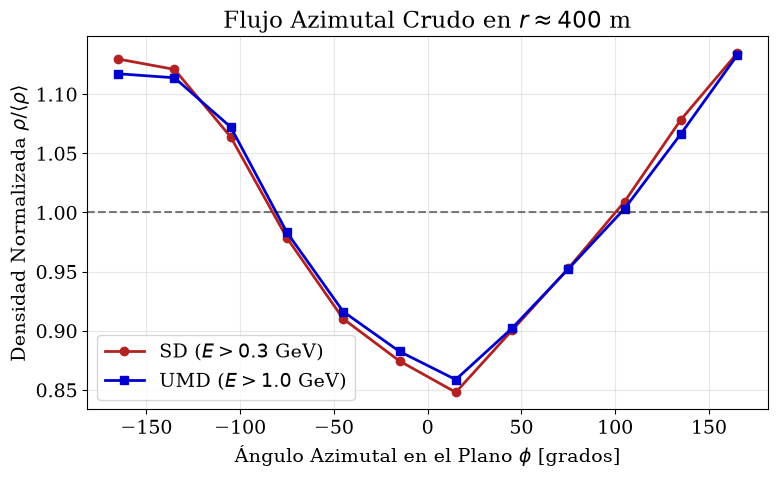

Procesando anillo en r = 1000 ± 50 m...


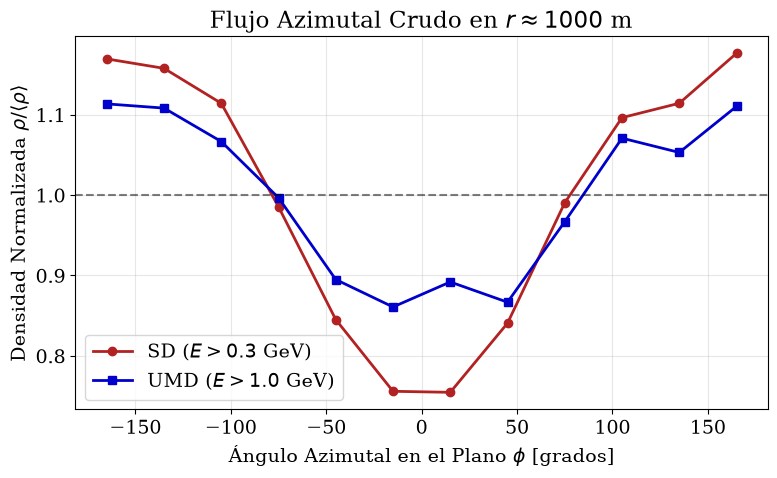

In [26]:
# =============================================================================
# 4. EXTRACCIÓN Y VISUALIZACIÓN DE HISTOGRAMAS AZIMUTALES
# =============================================================================
def plot_raw_azimuthal_distribution(files, radius_target, dr=50):
    """
    Filtra los datos crudos en un anillo r +/- dr y grafica la densidad de flujo.
    """
    phi_bins = np.linspace(-180, 180, 13)
    phi_centers = 0.5 * (phi_bins[1:] + phi_bins[:-1])
    
    counts_SD = np.zeros(12)
    counts_UMD = np.zeros(12)
    
    print(f"Procesando anillo en r = {radius_target} ± {dr} m...")
    
    for file in files:
        df = pd.read_parquet(file, columns=['r', 'phi', 'E', 'weight'])
        
        # Filtro geométrico (Infill/Far-core)
        mask_r = (df['r'] >= radius_target - dr) & (df['r'] < radius_target + dr)
        df_ring = df[mask_r]
        
        if len(df_ring) == 0:
            continue
            
        # Filtros de energía de detectores
        mask_SD = df_ring['E'] >= E_th_SD
        mask_UMD = df_ring['E'] >= E_th_UMD
        
        c_SD, _ = np.histogram(df_ring.loc[mask_SD, 'phi'], bins=phi_bins, weights=df_ring.loc[mask_SD, 'weight'])
        c_UMD, _ = np.histogram(df_ring.loc[mask_UMD, 'phi'], bins=phi_bins, weights=df_ring.loc[mask_UMD, 'weight'])
        
        counts_SD += c_SD
        counts_UMD += c_UMD
        
        del df, df_ring
        gc.collect()

    # Normalización al valor medio para comparar morfología
    norm_SD = counts_SD / np.mean(counts_SD) if np.mean(counts_SD) > 0 else counts_SD
    norm_UMD = counts_UMD / np.mean(counts_UMD) if np.mean(counts_UMD) > 0 else counts_UMD
    
    # Gráfico estilo Auger
    plt.rcParams.update({'font.size': 14, 'axes.labelsize': 14, 'font.family': 'serif'})
    plt.figure(figsize=(8, 5))
    
    plt.plot(phi_centers, norm_SD, marker='o', color='firebrick', linewidth=2, label=r'SD ($E > 0.3$ GeV)')
    plt.plot(phi_centers, norm_UMD, marker='s', color='mediumblue', linewidth=2, label=r'UMD ($E > 1.0$ GeV)')
    
    plt.axhline(1.0, color='k', linestyle='--', alpha=0.5)
    
    # FIX: 'fr' le dice a Python que formatee las variables {} pero que ignore los escapes de LaTeX como \approx
    plt.title(fr'Flujo Azimutal Crudo en $r \approx {radius_target}$ m')
    plt.xlabel(r'Ángulo Azimutal en el Plano $\phi$ [grados]')
    
    # FIX: 'r' le dice a Python que deje las barras invertidas intactas para LaTeX
    plt.ylabel(r'Densidad Normalizada $\rho / \langle \rho \rangle$')
    
    # Invertir eje X temporalmente si querés que early (0) esté en el centro visual
    # plt.xlim(180, -180) 
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Graficamos un anillo cerca del core y otro en la zona far-core
plot_raw_azimuthal_distribution(saved_files, radius_target=400)
plot_raw_azimuthal_distribution(saved_files, radius_target=1000)

In [16]:
# =============================================================================
# 2. FUNCIONES WORKER Y PROCESAMIENTO FÍSICO (SOLO ATENUACIÓN)
# =============================================================================
def generate_and_save_chunk(args):
    chunk_id, N_chunk = args
    np.random.seed() 
    
    # 1. Cinemática Inicial
    z = np.random.gamma(shape=10.0, scale=300.0, size=N_chunk) 
    phi = np.random.uniform(-180, 180, N_chunk)
    
    u = np.random.uniform(0, 1, N_chunk)
    E_min, E_max = 0.1, 50.0 
    E = E_min * (1 - u * (1 - (E_min/E_max)**(gamma_idx-1))) ** (-1 / (gamma_idx - 1))
    
    pT = np.random.normal(pT_mean, 0.05, N_chunk)
    pT = np.clip(pT, 0.1, None)
    
    r = z * (pT / E)
    
    df = pd.DataFrame({'E': E, 'z': z, 'phi': phi, 'r': r})
    phi_rad = np.radians(df['phi'])
    
    # ---------------------------------------------------------
    # 2. Peso Geométrico (Mapeo de Billoir/Cazón)
    # APAGADO PARA DEBUGGING FENOMENOLÓGICO: Forzamos w_geo = 1.0
    # ---------------------------------------------------------
    w_geo = 1.0 
    
    # 3. Peso de Atenuación (Decaimiento Atmosférico)
    # early (phi=0): l_path es MENOR, mayor supervivencia -> asimetría positiva
    l_path = df['z'] - df['r'] * np.tan(theta_rad) * np.cos(phi_rad)
    lorentz_gamma = df['E'] / m_mu
    
    decay_arg = np.clip(l_path / (lorentz_gamma * c_tau), -50, 100)
    w_decay = np.exp(-decay_arg)
    
    # Densidad aparente final (Solo dominada por la atenuación)
    df['weight'] = w_geo * w_decay
    
    filename = os.path.join(OUTPUT_DIR, f"chunk_{chunk_id}.parquet")
    df.to_parquet(filename, index=False)
    
    del df
    gc.collect()
    
    return filename

In [17]:
# =============================================================================
# 3. EJECUCIÓN PARALELA (BIG DATA PIPELINE)
# =============================================================================
N_total = 10_000_000
n_cores = 8 # Dejamos 2 libres para que no se congele el sistema operativo
chunk_size = N_total // n_cores

print(f"Iniciando simulación fenomenológica de {N_total:.1e} eventos...")
print(f"Distribuyendo en {n_cores} cores. Destino: ./{OUTPUT_DIR}/")

start_time = time.time()

# Preparamos los argumentos para cada proceso worker
worker_args = [(i, chunk_size) for i in range(n_cores)]

# Ejecución paralela segura para Jupyter
with mp.Pool(processes=n_cores) as pool:
    saved_files = pool.map(generate_and_save_chunk, worker_args)
    
print(f"¡Generación completada en {time.time() - start_time:.2f} segundos!")
print("Todos los chunks están persistidos en disco. RAM liberada.")

Iniciando simulación fenomenológica de 1.0e+07 eventos...
Distribuyendo en 8 cores. Destino: ./toy_model_data/
¡Generación completada en 11.50 segundos!
Todos los chunks están persistidos en disco. RAM liberada.


Procesando anillo en r = 400 ± 200 m...


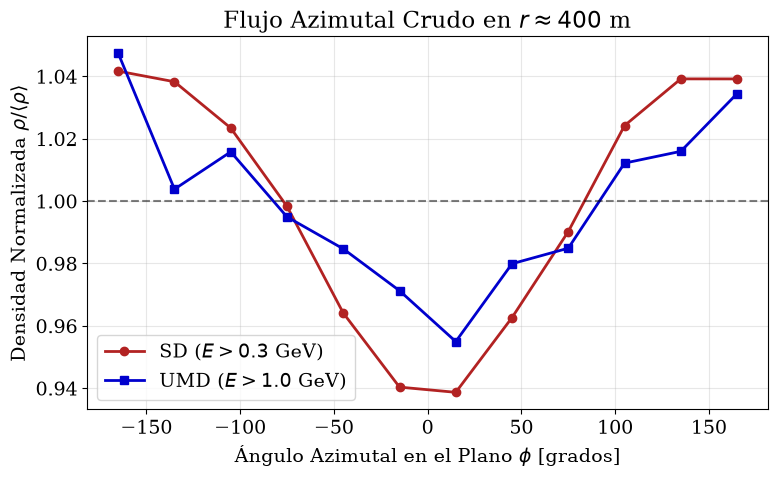

Procesando anillo en r = 1000 ± 200 m...


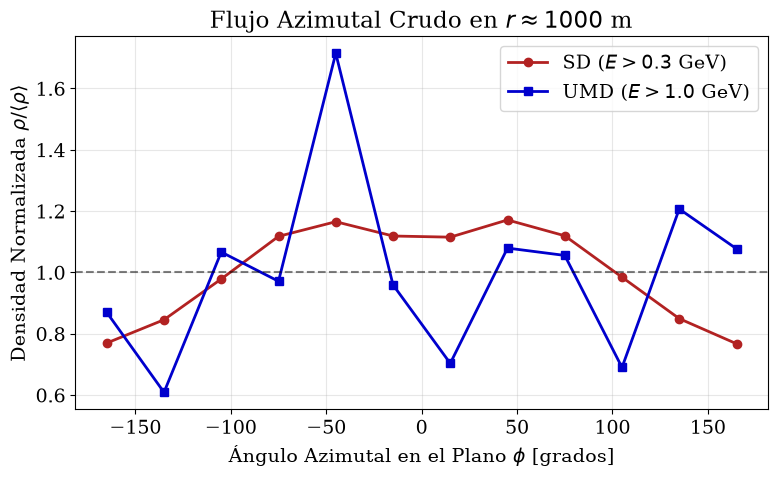

In [35]:
# =============================================================================
# 4. EXTRACCIÓN Y VISUALIZACIÓN DE HISTOGRAMAS AZIMUTALES
# =============================================================================
def plot_raw_azimuthal_distribution(files, radius_target, dr=50):
    """
    Filtra los datos crudos en un anillo r +/- dr y grafica la densidad de flujo.
    """
    phi_bins = np.linspace(-180, 180, 13)
    phi_centers = 0.5 * (phi_bins[1:] + phi_bins[:-1])
    
    counts_SD = np.zeros(12)
    counts_UMD = np.zeros(12)
    
    print(f"Procesando anillo en r = {radius_target} ± {dr} m...")
    
    for file in files:
        df = pd.read_parquet(file, columns=['r', 'phi', 'E', 'weight'])
        
        # Filtro geométrico (Infill/Far-core)
        mask_r = (df['r'] >= radius_target - dr) & (df['r'] < radius_target + dr)
        df_ring = df[mask_r]
        
        if len(df_ring) == 0:
            continue
            
        # Filtros de energía de detectores
        mask_SD = df_ring['E'] >= E_th_SD
        mask_UMD = df_ring['E'] >= E_th_UMD
        
        c_SD, _ = np.histogram(df_ring.loc[mask_SD, 'phi'], bins=phi_bins, weights=df_ring.loc[mask_SD, 'weight'])
        c_UMD, _ = np.histogram(df_ring.loc[mask_UMD, 'phi'], bins=phi_bins, weights=df_ring.loc[mask_UMD, 'weight'])
        
        counts_SD += c_SD
        counts_UMD += c_UMD
        
        del df, df_ring
        gc.collect()

    # Normalización al valor medio para comparar morfología
    norm_SD = counts_SD / np.mean(counts_SD) if np.mean(counts_SD) > 0 else counts_SD
    norm_UMD = counts_UMD / np.mean(counts_UMD) if np.mean(counts_UMD) > 0 else counts_UMD
    
    # Gráfico estilo Auger
    plt.rcParams.update({'font.size': 14, 'axes.labelsize': 14, 'font.family': 'serif'})
    plt.figure(figsize=(8, 5))
    
    plt.plot(phi_centers, norm_SD, marker='o', color='firebrick', linewidth=2, label=r'SD ($E > 0.3$ GeV)')
    plt.plot(phi_centers, norm_UMD, marker='s', color='mediumblue', linewidth=2, label=r'UMD ($E > 1.0$ GeV)')
    
    plt.axhline(1.0, color='k', linestyle='--', alpha=0.5)
    
    # FIX: 'fr' le dice a Python que formatee las variables {} pero que ignore los escapes de LaTeX como \approx
    plt.title(fr'Flujo Azimutal Crudo en $r \approx {radius_target}$ m')
    plt.xlabel(r'Ángulo Azimutal en el Plano $\phi$ [grados]')
    
    # FIX: 'r' le dice a Python que deje las barras invertidas intactas para LaTeX
    plt.ylabel(r'Densidad Normalizada $\rho / \langle \rho \rangle$')
    
    # Invertir eje X temporalmente si querés que early (0) esté en el centro visual
    # plt.xlim(180, -180) 
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Graficamos un anillo cerca del core y otro en la zona far-core
plot_raw_azimuthal_distribution(saved_files, radius_target=400)
plot_raw_azimuthal_distribution(saved_files, radius_target=1000)

Leyendo chunks para calcular cinemática angular...


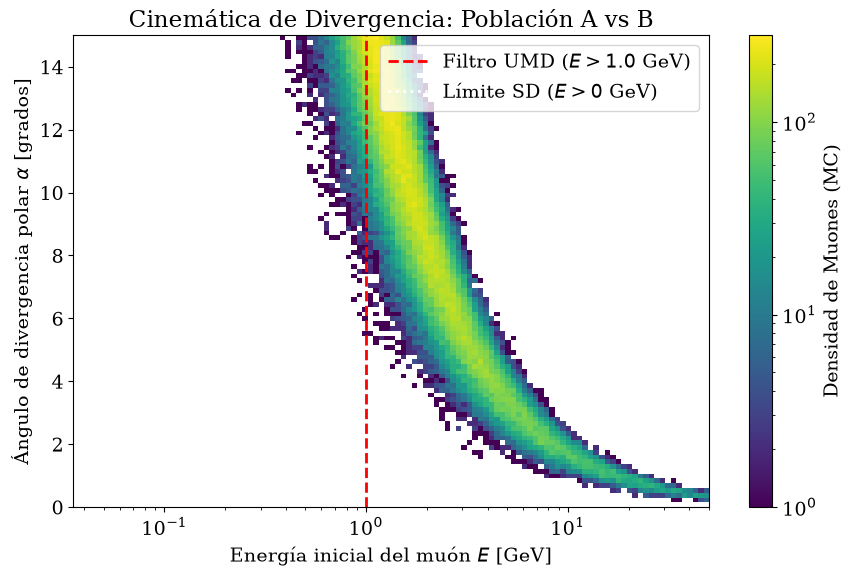

In [27]:
def plot_divergence_angle_vs_energy(files):
    """
    Calcula el ángulo de divergencia polar alpha = arctan(r/z) 
    y grafica un histograma 2D contra la energía para visualizar el Filtro Cinemático.
    """
    print("Leyendo chunks para calcular cinemática angular...")
    
    E_all = []
    alpha_all = []
    
    # Leemos solo una fracción de los datos para que el plot 2D no explote la RAM
    for file in files[:4]: # Con 4 chunks (aprox 2.8M eventos) sobra estadística
        df = pd.read_parquet(file, columns=['E', 'r', 'z'])
        
        # Calculamos el ángulo polar de apertura (en grados)
        alpha_deg = np.degrees(np.arctan(df['r'] / df['z']))
        
        E_all.append(df['E'].values)
        alpha_all.append(alpha_deg.values)
        
        del df
        gc.collect()

    E_array = np.concatenate(E_all)
    alpha_array = np.concatenate(alpha_all)

    # Gráfico estilo Auger
    plt.rcParams.update({'font.size': 14, 'axes.labelsize': 14, 'font.family': 'serif'})
    fig, ax = plt.subplots(figsize=(9, 6))
    
    # Histograma 2D en escala logarítmica para ver la dominancia de bajas energías
    h = ax.hist2d(E_array, alpha_array, bins=[np.logspace(-1, 1.7, 100), np.linspace(0, 15, 100)], 
                  cmap='viridis', norm=mcolors.LogNorm())
    
    fig.colorbar(h[3], ax=ax, label='Densidad de Muones (MC)')
    
    # Líneas de corte de los detectores
    ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label=r'Filtro UMD ($E > 1.0$ GeV)')
    ax.axvline(x=0.05, color='white', linestyle=':', linewidth=2, label=r'Límite SD ($E > 0$ GeV)')
    
    ax.set_xscale('log')
    ax.set_xlabel(r'Energía inicial del muón $E$ [GeV]')
    ax.set_ylabel(r'Ángulo de divergencia polar $\alpha$ [grados]')
    ax.set_title('Cinemática de Divergencia: Población A vs B')
    
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Ejecutar el ploteo (asegurate de pasarle la lista de 'saved_files' que tenías en memoria)
plot_divergence_angle_vs_energy(saved_files)

In [32]:
# =============================================================================
# 2. FUNCIONES WORKER Y PROCESAMIENTO FÍSICO (MODELO COMPLETO ACOPLADO)
# =============================================================================
def generate_and_save_chunk(args):
    chunk_id, N_chunk = args
    np.random.seed()
    
    # 1. Sorteamos la Energía primero (Ley de potencias)
    u = np.random.uniform(0, 1, N_chunk)
    E_min, E_max = 0.1, 50.0 
    E = E_min * (1 - u * (1 - (E_min/E_max)**(gamma_idx-1))) ** (-1 / (gamma_idx - 1))
    
    # 2. Acoplamiento Físico: Altura (z) en función de la Energía (E)
    # Los muones de mayor energía nacen más alto en la cascada.
    # Usamos un factor logarítmico para escalar la altura media de la distribución Gamma.
    z_scale_base = 250.0
    z_scale_coupled = z_scale_base + 120.0 * np.log10(E / E_min)
    z = np.random.gamma(shape=10.0, scale=z_scale_coupled)
    
    phi = np.random.uniform(-180, 180, N_chunk)
    
    pT = np.random.normal(pT_mean, 0.05, N_chunk)
    pT = np.clip(pT, 0.1, None)
    
    r = z * (pT / E)
    
    df = pd.DataFrame({'E': E, 'z': z, 'phi': phi, 'r': r})
    phi_rad = np.radians(df['phi'])
    
    # ---------------------------------------------------------
    # 3. Competencia Fenomenológica (Geometría vs Atenuación)
    # ---------------------------------------------------------
    
    # Efecto Geométrico (Billoir / Pryke) - PRENDIDO
    # Expande área en early (phi=0), bajando densidad (asimetría negativa)
    w_geo = 1.0 - (df['r'] / df['z']) * np.tan(theta_rad) * np.cos(phi_rad)
    w_geo = np.clip(w_geo, 0.0, None)
    
    # Efecto de Atenuación Atmosférica
    # Menor recorrido l_path en early (phi=0), mayor supervivencia (asimetría positiva)
    l_path = df['z'] - df['r'] * np.tan(theta_rad) * np.cos(phi_rad)
    lorentz_gamma = df['E'] / m_mu
    
    decay_arg = np.clip(l_path / (lorentz_gamma * c_tau), -50, 100)
    w_decay = np.exp(-decay_arg)
    
    # Densidad final
    df['weight'] = w_geo * w_decay
    
    # 4. Guardado a disco
    filename = os.path.join(OUTPUT_DIR, f"chunk_{chunk_id}.parquet")
    df.to_parquet(filename, index=False)
    
    del df
    gc.collect()
    
    return filename

In [33]:
# =============================================================================
# 3. EJECUCIÓN PARALELA (BIG DATA PIPELINE)
# =============================================================================
N_total = 10_000_000
n_cores = 8 # Dejamos 2 libres para que no se congele el sistema operativo
chunk_size = N_total // n_cores

print(f"Iniciando simulación fenomenológica de {N_total:.1e} eventos...")
print(f"Distribuyendo en {n_cores} cores. Destino: ./{OUTPUT_DIR}/")

start_time = time.time()

# Preparamos los argumentos para cada proceso worker
worker_args = [(i, chunk_size) for i in range(n_cores)]

# Ejecución paralela segura para Jupyter
with mp.Pool(processes=n_cores) as pool:
    saved_files = pool.map(generate_and_save_chunk, worker_args)
    
print(f"¡Generación completada en {time.time() - start_time:.2f} segundos!")
print("Todos los chunks están persistidos en disco. RAM liberada.")

Iniciando simulación fenomenológica de 1.0e+07 eventos...
Distribuyendo en 8 cores. Destino: ./toy_model_data/
¡Generación completada en 8.33 segundos!
Todos los chunks están persistidos en disco. RAM liberada.


Procesando anillo en r = 400 ± 50 m...


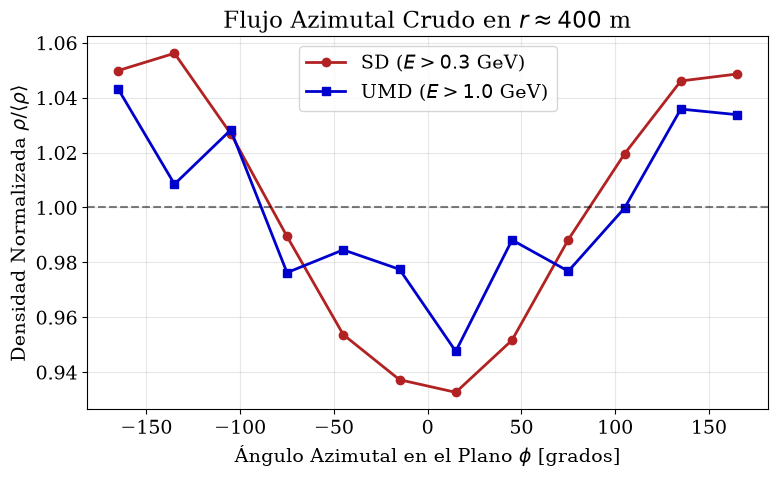

Procesando anillo en r = 1000 ± 50 m...


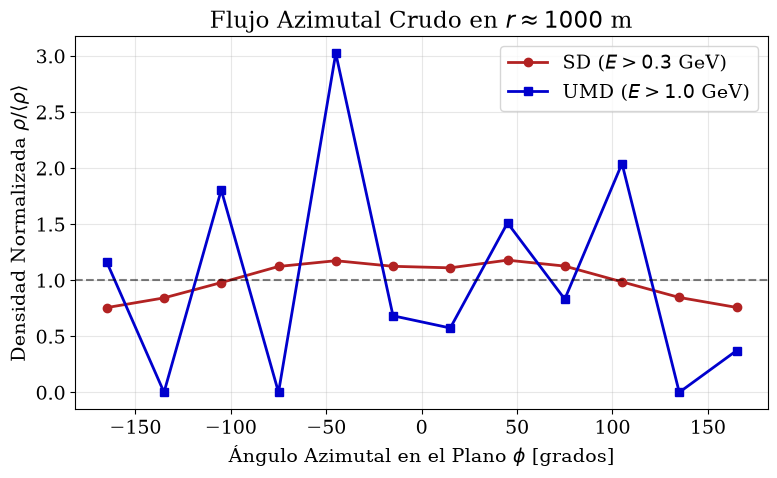

In [34]:
# =============================================================================
# 4. EXTRACCIÓN Y VISUALIZACIÓN DE HISTOGRAMAS AZIMUTALES
# =============================================================================
def plot_raw_azimuthal_distribution(files, radius_target, dr=50):
    """
    Filtra los datos crudos en un anillo r +/- dr y grafica la densidad de flujo.
    """
    phi_bins = np.linspace(-180, 180, 13)
    phi_centers = 0.5 * (phi_bins[1:] + phi_bins[:-1])
    
    counts_SD = np.zeros(12)
    counts_UMD = np.zeros(12)
    
    print(f"Procesando anillo en r = {radius_target} ± {dr} m...")
    
    for file in files:
        df = pd.read_parquet(file, columns=['r', 'phi', 'E', 'weight'])
        
        # Filtro geométrico (Infill/Far-core)
        mask_r = (df['r'] >= radius_target - dr) & (df['r'] < radius_target + dr)
        df_ring = df[mask_r]
        
        if len(df_ring) == 0:
            continue
            
        # Filtros de energía de detectores
        mask_SD = df_ring['E'] >= E_th_SD
        mask_UMD = df_ring['E'] >= E_th_UMD
        
        c_SD, _ = np.histogram(df_ring.loc[mask_SD, 'phi'], bins=phi_bins, weights=df_ring.loc[mask_SD, 'weight'])
        c_UMD, _ = np.histogram(df_ring.loc[mask_UMD, 'phi'], bins=phi_bins, weights=df_ring.loc[mask_UMD, 'weight'])
        
        counts_SD += c_SD
        counts_UMD += c_UMD
        
        del df, df_ring
        gc.collect()

    # Normalización al valor medio para comparar morfología
    norm_SD = counts_SD / np.mean(counts_SD) if np.mean(counts_SD) > 0 else counts_SD
    norm_UMD = counts_UMD / np.mean(counts_UMD) if np.mean(counts_UMD) > 0 else counts_UMD
    
    # Gráfico estilo Auger
    plt.rcParams.update({'font.size': 14, 'axes.labelsize': 14, 'font.family': 'serif'})
    plt.figure(figsize=(8, 5))
    
    plt.plot(phi_centers, norm_SD, marker='o', color='firebrick', linewidth=2, label=r'SD ($E > 0.3$ GeV)')
    plt.plot(phi_centers, norm_UMD, marker='s', color='mediumblue', linewidth=2, label=r'UMD ($E > 1.0$ GeV)')
    
    plt.axhline(1.0, color='k', linestyle='--', alpha=0.5)
    
    # FIX: 'fr' le dice a Python que formatee las variables {} pero que ignore los escapes de LaTeX como \approx
    plt.title(fr'Flujo Azimutal Crudo en $r \approx {radius_target}$ m')
    plt.xlabel(r'Ángulo Azimutal en el Plano $\phi$ [grados]')
    
    # FIX: 'r' le dice a Python que deje las barras invertidas intactas para LaTeX
    plt.ylabel(r'Densidad Normalizada $\rho / \langle \rho \rangle$')
    
    # Invertir eje X temporalmente si querés que early (0) esté en el centro visual
    # plt.xlim(180, -180) 
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Graficamos un anillo cerca del core y otro en la zona far-core
plot_raw_azimuthal_distribution(saved_files, radius_target=400)
plot_raw_azimuthal_distribution(saved_files, radius_target=1000)